# FIFA Player Market & Performance Analytics ⚽📊

FIFA 21 player analysis for a Data Analyst portfolio.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


## 2. Load FIFA 21 Data

In [2]:
df = pd.read_csv('../data/players_21.csv')
df.head()


,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club_name,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,33,1987-06-24,170,72,Argentina,FC Barcelona,...,66+3,65+3,65+3,65+3,66+3,62+3,52+3,52+3,52+3,62+3
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,35,1985-02-05,187,83,Portugal,Juventus,...,65+3,61+3,61+3,61+3,65+3,61+3,54+3,54+3,54+3,61+3
2,200389,https://sofifa.com/player/200389/jan-oblak/210002,J. Oblak,Jan Oblak,27,1993-01-07,188,87,Slovenia,Atlético Madrid,...,32+3,36+3,36+3,36+3,32+3,32+3,33+3,33+3,33+3,32+3
3,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,31,1988-08-21,184,80,Poland,FC Bayern München,...,64+3,65+3,65+3,65+3,64+3,61+3,60+3,60+3,60+3,61+3
4,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,28,1992-02-05,175,68,Brazil,Paris Saint-Germain,...,67+3,62+3,62+3,62+3,67+3,62+3,49+3,49+3,49+3,62+3


In [3]:
print("Dataset shape:", df.shape)
print("Number of players:", len(df))


Dataset shape: (18944, 106)
Number of players: 18944


## 3. Understand the Dataset

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18944 entries, 0 to 18943
Columns: 106 entries, sofifa_id to rb
dtypes: float64(18), int64(44), object(44)
memory usage: 15.3+ MB


In [5]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
sofifa_id,18944.0,226242.402872,27171.091056,41.0,210030.5,232314.5,246760.25,258970.0
age,18944.0,25.225823,4.697354,16.0,21.0,25.0,29.00,53.0
height_cm,18944.0,181.190773,6.825672,155.0,176.0,181.0,186.00,206.0
weight_kg,18944.0,75.016892,7.057140,50.0,70.0,75.0,80.00,110.0
league_rank,18719.0,1.357070,0.739327,1.0,1.0,1.0,1.00,4.0
...,...,...,...,...,...,...,...,...
goalkeeping_diving,18944.0,16.446052,17.577332,1.0,8.0,11.0,14.00,90.0
goalkeeping_handling,18944.0,16.236486,16.845480,1.0,8.0,11.0,14.00,92.0
goalkeeping_kicking,18944.0,16.103357,16.519399,1.0,8.0,11.0,14.00,93.0
goalkeeping_positioning,18944.0,16.225982,17.017341,1.0,8.0,11.0,14.00,91.0


In [6]:
df.isnull().sum().sort_values(ascending=False).head(20)


defending_marking       18944
loaned_from             18186
nation_jersey_number    17817
nation_position         17817
player_tags             17536
gk_speed                16861
gk_kicking              16861
gk_handling             16861
gk_diving               16861
gk_positioning          16861
gk_reflexes             16861
player_traits           10629
physic                   2083
defending                2083
dribbling                2083
passing                  2083
shooting                 2083
pace                     2083
release_clause_eur        995
joined                    983
dtype: int64

## 4. Select Relevant Columns

In [32]:
columns = [
    'sofifa_id',
    'short_name',
    'age',
    'nationality',
    'club_name',
    'player_positions',
    'overall',
    'potential',
    'value_eur',
    'wage_eur',
    'pace',
    'shooting',
    'passing',
    'dribbling',
    'defending',
    'physic'
]

analysis_df = df[columns].copy()

analysis_df.head()

,sofifa_id,short_name,age,nationality,club_name,player_positions,overall,potential,value_eur,wage_eur,pace,shooting,passing,dribbling,defending,physic
0,158023,L. Messi,33,Argentina,FC Barcelona,"RW, ST, CF",93,93,67500000,560000,85.0,92.0,91.0,95.0,38.0,65.0
1,20801,Cristiano Ronaldo,35,Portugal,Juventus,"ST, LW",92,92,46000000,220000,89.0,93.0,81.0,89.0,35.0,77.0
2,200389,J. Oblak,27,Slovenia,Atlético Madrid,GK,91,93,75000000,125000,NaN,NaN,NaN,NaN,NaN,NaN
3,188545,R. Lewandowski,31,Poland,FC Bayern München,ST,91,91,80000000,240000,78.0,91.0,78.0,85.0,43.0,82.0
4,190871,Neymar Jr,28,Brazil,Paris Saint-Germain,"LW, CAM",91,91,90000000,270000,91.0,85.0,86.0,94.0,36.0,59.0


In [33]:
analysis_df.isnull().sum()

sofifa_id              0
short_name             0
age                    0
nationality            0
club_name            225
player_positions       0
overall                0
potential              0
value_eur              0
wage_eur               0
pace                2083
shooting            2083
passing             2083
dribbling           2083
defending           2083
physic              2083
dtype: int64

## 5. Data Cleaning

In [34]:
numeric_columns = [
    'age', 'overall', 'potential', 'value_eur', 'wage_eur',
    'pace', 'shooting', 'passing', 'dribbling',
    'defending', 'physic'
]

analysis_df[numeric_columns] = analysis_df[numeric_columns].apply(
    pd.to_numeric, errors='coerce'
)

print("Shape after basic cleaning:", analysis_df.shape)

clean_df = analysis_df.copy()

clean_df['club_name'] = clean_df['club_name'].fillna('Unknown')

clean_df['is_goalkeeper'] = clean_df['player_positions'].str.contains(
    'GK',
    na=False
)

print("Original df:", df.shape)
print("Analysis df:", analysis_df.shape)
print("Clean df:", clean_df.shape)

print("Duplicate FIFA IDs:", analysis_df['sofifa_id'].duplicated().sum())
print("Rows:", len(clean_df))
print("Goalkeepers:", clean_df['is_goalkeeper'].sum())
print("Missing club names:", clean_df['club_name'].isnull().sum())

Shape after basic cleaning: (18944, 16)
Original df: (18944, 106)
Analysis df: (18944, 16)
Clean df: (18944, 17)
Duplicate FIFA IDs: 0
Rows: 18944
Goalkeepers: 2084
Missing club names: 0


## 6. Feature Engineering

In [35]:
# Feature Engineering

clean_df['growth_gap'] = (
    clean_df['potential'] - clean_df['overall']
)

clean_df['value_per_rating'] = (
    clean_df['value_eur'] /
    clean_df['overall'].replace(0, np.nan)
)

clean_df.head()

,sofifa_id,short_name,age,nationality,club_name,player_positions,overall,potential,value_eur,wage_eur,pace,shooting,passing,dribbling,defending,physic,is_goalkeeper,growth_gap,value_per_rating
0,158023,L. Messi,33,Argentina,FC Barcelona,"RW, ST, CF",93,93,67500000,560000,85.0,92.0,91.0,95.0,38.0,65.0,False,0,725806.451613
1,20801,Cristiano Ronaldo,35,Portugal,Juventus,"ST, LW",92,92,46000000,220000,89.0,93.0,81.0,89.0,35.0,77.0,False,0,500000.000000
2,200389,J. Oblak,27,Slovenia,Atlético Madrid,GK,91,93,75000000,125000,NaN,NaN,NaN,NaN,NaN,NaN,True,2,824175.824176
3,188545,R. Lewandowski,31,Poland,FC Bayern München,ST,91,91,80000000,240000,78.0,91.0,78.0,85.0,43.0,82.0,False,0,879120.879121
4,190871,Neymar Jr,28,Brazil,Paris Saint-Germain,"LW, CAM",91,91,90000000,270000,91.0,85.0,86.0,94.0,36.0,59.0,False,0,989010.989011


In [58]:
screen_df = clean_df[
    features + ['sofifa_id', 'short_name', 'club_name', 'value_eur']
].dropna().copy()

screen_df['predicted_value'] = model.predict(
    screen_df[features]
)

screen_df['value_gap'] = (
    screen_df['predicted_value'] -
    screen_df['value_eur']
)

screen_df.sort_values(
    'value_gap',
    ascending=False
)[
    [
        'short_name',
        'club_name',
        'value_eur',
        'predicted_value',
        'value_gap'
    ]
].head(10)

,short_name,club_name,value_eur,predicted_value,value_gap
363,Welington Dano,Unknown,0,1.129597e+07,1.129597e+07
359,Juiano Mestres,Unknown,0,1.089189e+07,1.089189e+07
498,L. Dálves,Unknown,0,9.857397e+06,9.857397e+06
583,J. Quintero,Unknown,0,9.787801e+06,9.787801e+06
501,J. Sildero,Unknown,0,9.738591e+06,9.738591e+06
680,R. Di Leonardo,Unknown,0,9.266666e+06,9.266666e+06
497,S. Ardero,Unknown,0,9.178117e+06,9.178117e+06
500,E. Schetino,Unknown,0,9.024641e+06,9.024641e+06
528,W. Barrios,Unknown,0,8.914060e+06,8.914060e+06
502,S. Mandíquez,Unknown,0,8.864720e+06,8.864720e+06


In [36]:
clean_df['age_group'] = pd.cut(
    clean_df['age'],
    bins=[0, 20, 24, 28, 32, 100],
    labels=[
        'Under 20',
        '20-24',
        '25-28',
        '29-32',
        '33+'
    ]
)

clean_df.head()

,sofifa_id,short_name,age,nationality,club_name,player_positions,overall,potential,value_eur,wage_eur,pace,shooting,passing,dribbling,defending,physic,is_goalkeeper,growth_gap,value_per_rating,age_group
0,158023,L. Messi,33,Argentina,FC Barcelona,"RW, ST, CF",93,93,67500000,560000,85.0,92.0,91.0,95.0,38.0,65.0,False,0,725806.451613,33+
1,20801,Cristiano Ronaldo,35,Portugal,Juventus,"ST, LW",92,92,46000000,220000,89.0,93.0,81.0,89.0,35.0,77.0,False,0,500000.000000,33+
2,200389,J. Oblak,27,Slovenia,Atlético Madrid,GK,91,93,75000000,125000,NaN,NaN,NaN,NaN,NaN,NaN,True,2,824175.824176,25-28
3,188545,R. Lewandowski,31,Poland,FC Bayern München,ST,91,91,80000000,240000,78.0,91.0,78.0,85.0,43.0,82.0,False,0,879120.879121,29-32
4,190871,Neymar Jr,28,Brazil,Paris Saint-Germain,"LW, CAM",91,91,90000000,270000,91.0,85.0,86.0,94.0,36.0,59.0,False,0,989010.989011,25-28


In [37]:
print(clean_df[
    [
        'short_name',
        'age',
        'overall',
        'potential',
        'growth_gap',
        'value_eur',
        'value_per_rating',
        'age_group'
    ]
].head(10))

          short_name  age  overall  potential  growth_gap  value_eur  \
0           L. Messi   33       93         93           0   67500000   
1  Cristiano Ronaldo   35       92         92           0   46000000   
2           J. Oblak   27       91         93           2   75000000   
3     R. Lewandowski   31       91         91           0   80000000   
4          Neymar Jr   28       91         91           0   90000000   
5       K. De Bruyne   29       91         91           0   87000000   
6          K. Mbappé   21       90         95           5  105500000   
7      M. ter Stegen   28       90         93           3   69500000   
8        V. van Dijk   28       90         91           1   75500000   
9            Alisson   27       90         91           1   62500000   

   value_per_rating age_group  
0      7.258065e+05       33+  
1      5.000000e+05       33+  
2      8.241758e+05     25-28  
3      8.791209e+05     29-32  
4      9.890110e+05     25-28  
5      9.560440

In [38]:
print(clean_df['age_group'].value_counts().sort_index())

age_group
Under 20    3429
20-24       5714
25-28       5018
29-32       3376
33+         1407
Name: count, dtype: int64


In [50]:
club_analysis = (
    clean_df.groupby('club_name')
    .agg(
        players=('sofifa_id', 'count'),
        avg_overall=('overall', 'mean'),
        total_value=('value_eur', 'sum'),
        total_wage=('wage_eur', 'sum')
    )
    .sort_values('total_value', ascending=False)
    .head(10)
)

club_analysis

,players,avg_overall,total_value,total_wage
club_name,,,,
Liverpool,33,78.575758,840625000,3154000
Real Madrid,32,79.250000,760850000,4848000
Manchester City,33,77.484848,747275000,3765000
FC Barcelona,33,78.909091,722200000,4738000
FC Bayern München,22,81.045455,609700000,1802000
Paris Saint-Germain,29,76.793103,605675000,2125550
Chelsea,33,79.212121,602275000,2698000
Atlético Madrid,33,77.181818,582500000,1597000
Tottenham Hotspur,33,77.242424,571525000,2542000


## 7. Highest Rated Players

In [39]:
top_rated = (
    clean_df[
        ['short_name', 'overall', 'potential', 'club_name', 'nationality']
    ]
    .sort_values('overall', ascending=False)
    .head(20)
)

top_rated

,short_name,overall,potential,club_name,nationality
0,L. Messi,93,93,FC Barcelona,Argentina
1,Cristiano Ronaldo,92,92,Juventus,Portugal
2,J. Oblak,91,93,Atlético Madrid,Slovenia
3,R. Lewandowski,91,91,FC Bayern München,Poland
4,Neymar Jr,91,91,Paris Saint-Germain,Brazil
5,K. De Bruyne,91,91,Manchester City,Belgium
9,Alisson,90,91,Liverpool,Brazil
10,S. Mané,90,90,Liverpool,Senegal
11,M. Salah,90,90,Liverpool,Egypt
8,V. van Dijk,90,91,Liverpool,Netherlands


In [41]:
top_potential = (
    clean_df[
        [
            'short_name',
            'overall',
            'potential',
            'growth_gap',
            'age',
            'club_name'
        ]
    ]
    .sort_values(
        ['potential', 'growth_gap'],
        ascending=[False, False]
    )
    .head(20)
)

top_potential

,short_name,overall,potential,growth_gap,age,club_name
6,K. Mbappé,90,95,5,21,Paris Saint-Germain
366,Vinícius Jr.,80,93,13,19,Real Madrid
272,João Félix,81,93,12,20,Atlético Madrid
62,K. Havertz,85,93,8,21,Chelsea
28,J. Sancho,87,93,6,20,Borussia Dortmund
7,M. ter Stegen,90,93,3,28,FC Barcelona
2,J. Oblak,91,93,2,27,Atlético Madrid
0,L. Messi,93,93,0,33,FC Barcelona
99,E. Haaland,84,92,8,19,Borussia Dortmund
63,G. Donnarumma,85,92,7,21,Milan


In [40]:
top_value = (
    clean_df[
        [
            'short_name',
            'value_eur',
            'overall',
            'potential',
            'age',
            'club_name'
        ]
    ]
    .sort_values('value_eur', ascending=False)
    .head(20)
)

top_value

,short_name,value_eur,overall,potential,age,club_name
6,K. Mbappé,105500000,90,95,21,Paris Saint-Germain
4,Neymar Jr,90000000,91,91,28,Paris Saint-Germain
5,K. De Bruyne,87000000,91,91,29,Manchester City
3,R. Lewandowski,80000000,91,91,31,FC Bayern München
10,S. Mané,78000000,90,90,28,Liverpool
11,M. Salah,78000000,90,90,28,Liverpool
8,V. van Dijk,75500000,90,91,28,Liverpool
2,J. Oblak,75000000,91,93,27,Atlético Madrid
19,R. Sterling,72500000,88,90,25,Manchester City
21,H. Kane,71000000,88,89,26,Tottenham Hotspur


## 8. Highest Market Value Players

In [42]:
top_value = (
    clean_df[
        ['short_name', 'value_eur', 'overall', 'age', 'club_name']
    ]
    .dropna(subset=['value_eur'])
    .sort_values('value_eur', ascending=False)
    .head(20)
)

top_value

,short_name,value_eur,overall,age,club_name
6,K. Mbappé,105500000,90,21,Paris Saint-Germain
4,Neymar Jr,90000000,91,28,Paris Saint-Germain
5,K. De Bruyne,87000000,91,29,Manchester City
3,R. Lewandowski,80000000,91,31,FC Bayern München
10,S. Mané,78000000,90,28,Liverpool
11,M. Salah,78000000,90,28,Liverpool
8,V. van Dijk,75500000,90,28,Liverpool
2,J. Oblak,75000000,91,27,Atlético Madrid
19,R. Sterling,72500000,88,25,Manchester City
21,H. Kane,71000000,88,26,Tottenham Hotspur


## 9. Position Analysis

In [43]:
position_summary = (
    clean_df
    .dropna(subset=['player_positions'])
    .groupby('player_positions')
    .agg(
        players=('short_name', 'count'),
        avg_overall=('overall', 'mean'),
        avg_value_eur=('value_eur', 'mean'),
        avg_wage_eur=('wage_eur', 'mean')
    )
    .query('players >= 20')
    .sort_values('avg_value_eur', ascending=False)
)

position_summary.round(2)

,players,avg_overall,avg_value_eur,avg_wage_eur
player_positions,,,,
"CF, ST",32,69.75,6573750.00,26818.75
"CAM, CM, RM",25,68.40,5423400.00,24620.00
"ST, LW, RW",25,65.40,5391400.00,12876.00
"CAM, RW",30,68.70,4821000.00,16428.33
"RW, RM",40,69.53,4564500.00,21962.50
...,...,...,...,...
CAM,268,62.10,1214048.51,3706.53
"LB, CB",109,64.65,1146834.86,5541.28
"LB, RB",55,64.60,1030181.82,4058.18


## 10. Rating Distribution

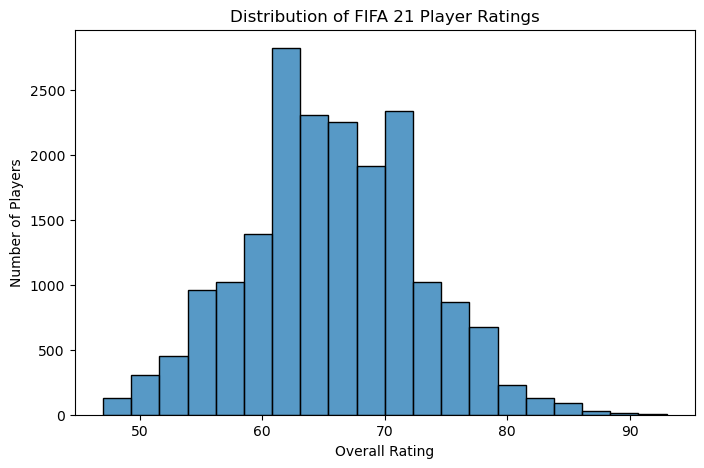

In [44]:
plt.figure(figsize=(8, 5))

sns.histplot(
    clean_df['overall'].dropna(),
    bins=20
)

plt.title('Distribution of FIFA 21 Player Ratings')
plt.xlabel('Overall Rating')
plt.ylabel('Number of Players')

plt.show()

## 11. Overall Rating vs Market Value

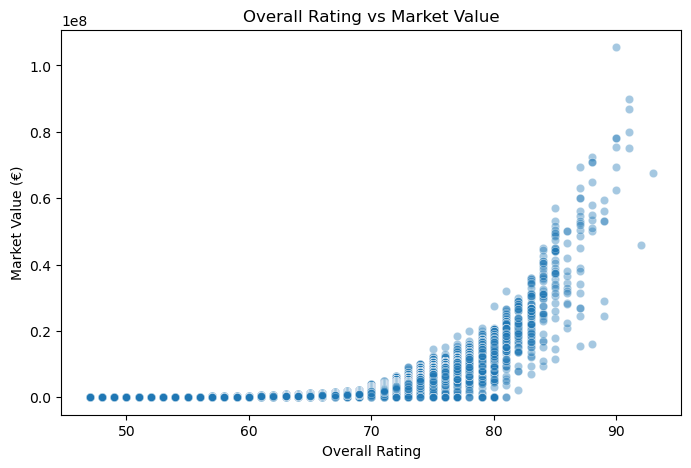

In [45]:
plot_df = clean_df[['overall', 'value_eur']].dropna()

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=plot_df,
    x='overall',
    y='value_eur',
    alpha=0.4
)

plt.title('Overall Rating vs Market Value')
plt.xlabel('Overall Rating')
plt.ylabel('Market Value (€)')

plt.show()


## 12. Correlation Analysis

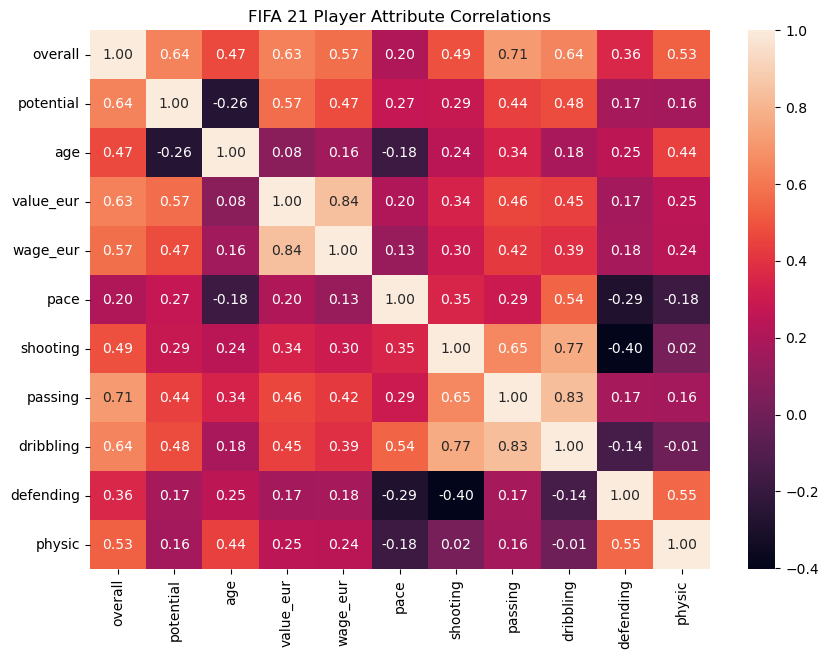

In [46]:
correlation_columns = [
    'overall', 'potential', 'age', 'value_eur', 'wage_eur',
    'pace', 'shooting', 'passing', 'dribbling',
    'defending', 'physic'
]

corr = clean_df[correlation_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f'
)

plt.title('FIFA 21 Player Attribute Correlations')

plt.show()

## 13. Linear Regression — Market Value

In [51]:
features = [
    'overall',
    'potential',
    'age',
    'pace',
    'shooting',
    'passing',
    'dribbling',
    'defending',
    'physic'
]

model_df = clean_df[features + ['value_eur']].dropna()

X = model_df[features]
y = model_df['value_eur']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

r2 = r2_score(y_test, predictions)

print("Linear Regression Results")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 3))

Linear Regression Results
MAE: 2032841.5
RMSE: 3903451.77
R²: 0.463


## 14. K-Means Player Segmentation

In [48]:
cluster_features = [
    'pace',
    'shooting',
    'passing',
    'dribbling',
    'defending',
    'physic'
]

cluster_data = clean_df[cluster_features].dropna().copy()

scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_data)

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_data['cluster'] = kmeans.fit_predict(scaled_data)

cluster_summary = (
    cluster_data
    .groupby('cluster')[cluster_features]
    .mean()
    .round(1)
)

cluster_summary

,pace,shooting,passing,dribbling,defending,physic
cluster,,,,,,
0,67.7,54.0,63.5,66.3,64.7,70.2
1,68.3,54.0,51.8,60.7,34.1,54.3
2,76.4,67.1,64.6,72.2,38.8,63.6
3,58.5,33.7,46.2,49.4,61.6,67.3


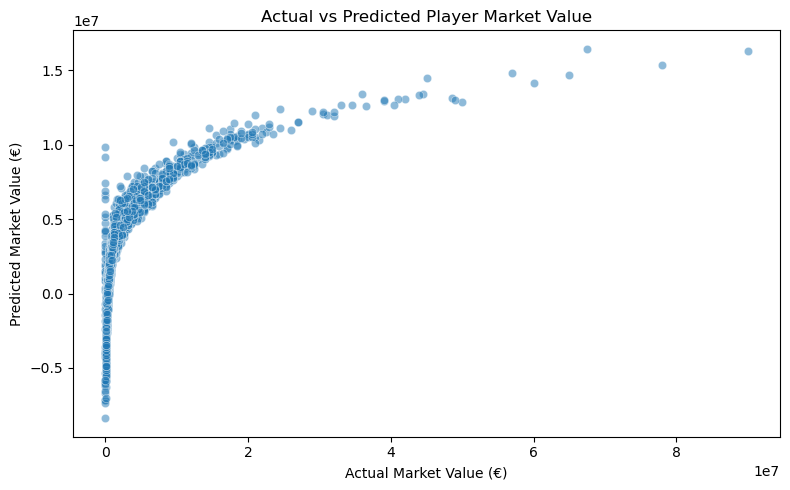

In [52]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_test,
    y=predictions,
    alpha=0.5
)

plt.xlabel('Actual Market Value (€)')
plt.ylabel('Predicted Market Value (€)')
plt.title('Actual vs Predicted Player Market Value')

plt.tight_layout()
plt.show()

## 15. Potentially Undervalued Players

In [49]:
screen_df = model_df.copy()

screen_df['predicted_value'] = model.predict(
    screen_df[features]
)

screen_df['value_gap'] = (
    screen_df['predicted_value'] -
    screen_df['value_eur']
)

screen_df.sort_values(
    'value_gap',
    ascending=False
).head(20)

,overall,potential,age,pace,shooting,passing,dribbling,defending,physic,value_eur,predicted_value,value_gap
363,81,81,20,79.0,54.0,76.0,78.0,75.0,74.0,0,1.129597e+07,1.129597e+07
359,81,81,24,71.0,61.0,57.0,62.0,82.0,80.0,0,1.089189e+07,1.089189e+07
498,80,80,28,80.0,82.0,60.0,71.0,34.0,75.0,0,9.857397e+06,9.857397e+06
583,79,80,27,71.0,76.0,81.0,83.0,39.0,51.0,0,9.787801e+06,9.787801e+06
501,80,80,28,81.0,77.0,80.0,79.0,40.0,71.0,0,9.738591e+06,9.738591e+06
680,79,79,24,78.0,51.0,69.0,78.0,76.0,67.0,0,9.266666e+06,9.266666e+06
497,80,80,32,82.0,72.0,77.0,83.0,26.0,51.0,0,9.178117e+06,9.178117e+06
500,80,80,28,80.0,43.0,56.0,65.0,82.0,76.0,0,9.024641e+06,9.024641e+06
528,79,84,26,73.0,38.0,66.0,69.0,79.0,84.0,0,8.914060e+06,8.914060e+06
502,80,80,31,80.0,80.0,56.0,74.0,29.0,80.0,0,8.864720e+06,8.864720e+06


In [53]:
clean_df.to_csv(
    '../data/fifa21_players_cleaned.csv',
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [59]:
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 3))

screen_df.sort_values(
    'value_gap',
    ascending=False
)[
    ['short_name', 'value_eur', 'predicted_value', 'value_gap']
].head(10)

MAE: 2032841.5
RMSE: 3903451.77
R²: 0.463


,short_name,value_eur,predicted_value,value_gap
363,Welington Dano,0,1.129597e+07,1.129597e+07
359,Juiano Mestres,0,1.089189e+07,1.089189e+07
498,L. Dálves,0,9.857397e+06,9.857397e+06
583,J. Quintero,0,9.787801e+06,9.787801e+06
501,J. Sildero,0,9.738591e+06,9.738591e+06
680,R. Di Leonardo,0,9.266666e+06,9.266666e+06
497,S. Ardero,0,9.178117e+06,9.178117e+06
500,E. Schetino,0,9.024641e+06,9.024641e+06
528,W. Barrios,0,8.914060e+06,8.914060e+06
502,S. Mandíquez,0,8.864720e+06,8.864720e+06


## 16. Final Business Insights

1. Liverpool had the highest total squad market value among the analyzed clubs, at approximately €840.6 million, followed by Real Madrid at €760.85 million and Manchester City at €747.28 million.

2. Bayern München had the highest average overall rating among the top 10 clubs by squad value, with an average rating of approximately 81.05.

3. Real Madrid had the highest total wage bill among the analyzed top clubs, at approximately €4.85 million, followed by FC Barcelona at approximately €4.74 million.

4. The player rating distribution shows that FIFA 21 contains a much larger number of average-rated players than elite-rated players, indicating that highly rated players represent a relatively small portion of the dataset.

5. Player market value generally increases with overall rating, although the relationship is not perfectly linear. This indicates that factors beyond overall rating also influence player valuation.

6. The K-Means analysis identified four distinct player profiles based on pace, shooting, passing, dribbling, defending, and physical attributes. Cluster 2 showed the strongest attacking profile, with the highest average pace (76.4), shooting (67.1), and dribbling (72.2).

7. Cluster 3 showed a more defensive and physical profile, with average defending of 61.6 and physicality of 67.3, while also having the lowest average shooting value of 33.7.

8. The Linear Regression model achieved an R² score of 0.463, with an MAE of approximately €2.03 million and RMSE of approximately €3.90 million. This indicates that the selected player attributes explain a meaningful but limited portion of the variation in market value.

